# Random forest climatology: Air temperature observations model for a cluster of stations

In this notebook, we model temperature over a region which represents a cluster of stations. We model using a random forest.
We load observations data with additional predictors (roughness, land fraction), apply suitable transformations.

Data: 

observations_qc.csv

land_fraction_data.csv

roughness_data.csv

We use additional predictors along with the intially provided covariates to potentially improve learning process of our models.

Model and libraries:
We use KMeans clustering to obtain a number of clusters of stations. 
We use scikit-learn to build random forest based climatology models and evaluate them with MAE metric.
Furthermore, we create various visual plots to analyse the results.


## Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.stats import norm

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from matplotlib.colors import LinearSegmentedColormap
from adjustText import adjust_text
import matplotlib.patheffects as pe

# Libraries for Neural Networks
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras import layers, models
import datetime
from tensorflow.keras.callbacks import TensorBoard
import keras
print(tf.__version__)

import keras_tuner
import math

#Random Forest Libraries
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import joblib

from sklearn.cluster import KMeans

2.19.0


## Loading Observations

In [4]:
obs = pd.read_csv('./datasets/observations_qc.csv', compression="gzip", parse_dates=["time"])
land_frac_data = pd.read_csv('./datasets/land_fraction_data.csv', compression="gzip")
roughness_data = pd.read_csv('./datasets/roughness_data.csv', compression="gzip")

obs = obs.merge(land_frac_data, how='left', on=['wmo_id','latitude','longitude', 'altitude'])
obs = obs.merge(roughness_data, how='left', on=['wmo_id','latitude','longitude', 'altitude'])

print(obs.shape)
print(obs.columns)
print((obs['ob_value']-273.15).min())
print((obs['ob_value']-273.15).max())

(9232630, 9)
Index(['ob_value', 'time', 'wmo_id', 'diagnostic', 'latitude', 'longitude',
       'altitude', 'land_fraction', 'roughness'],
      dtype='object')
-79.64999999999998
58.25


In [5]:
obs.head(10)

,ob_value,time,wmo_id,diagnostic,latitude,longitude,altitude,land_fraction,roughness
0,255.0,2025-02-01 02:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615
1,254.8,2025-02-01 04:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615
2,255.3,2025-02-01 06:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615
3,255.5,2025-02-01 07:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615
4,255.3,2025-02-01 08:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615
5,254.5,2025-02-01 09:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615
6,254.5,2025-02-01 10:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615
7,254.1,2025-02-01 12:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615
8,253.6,2025-02-01 13:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615
9,255.4,2025-02-01 19:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615


## Data Transformations

In [7]:
# Transforming date to a cyclic pattern in a 365 day cycle (obs -> observations)
obs['day_of_year'] = obs['time'].dt.dayofyear
obs['hour'] = pd.to_datetime(obs['time']).dt.hour
obs['sin_day'] = np.sin(2 * np.pi * obs['day_of_year'] / 365).round(5)
obs['cos_day'] = np.cos(2 * np.pi * obs['day_of_year'] / 365).round(5)
# Transforming time to a cyclic pattern - 24 hour cycle by calculating the solar time at positions
obs['sin_hour'] = np.sin(2 * np.pi * (obs['hour'] + 24 * (obs['longitude'] / 360)) / 24).round(5)
obs['cos_hour'] = np.cos(2 * np.pi * (obs['hour'] + 24 * (obs['longitude'] / 360)) / 24).round(5)

# Transforming latitude, longitude
obs['sin_lat'] = np.sin(np.radians(obs['latitude'])).round(5)
obs['cos_lat'] = np.cos(np.radians(obs['latitude'])).round(5)
obs['sin_long'] = np.sin(np.radians(obs['longitude'])).round(5)
obs['cos_long'] = np.cos(np.radians(obs['longitude'])).round(5)
# Converting temperature from Kelvin to Celsius 
obs['temp_celcius'] = obs['ob_value'] - 273.15

In [8]:
obs.head(10)

,ob_value,time,wmo_id,diagnostic,latitude,longitude,altitude,land_fraction,roughness,day_of_year,hour,sin_day,cos_day,sin_hour,cos_hour,sin_lat,cos_lat,sin_long,cos_long,temp_celcius
0,255.0,2025-02-01 02:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615,32,2,0.52342,0.85208,-0.76034,0.64953,-0.99452,0.10453,-0.98324,0.18234,-18.15
1,254.8,2025-02-01 04:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615,32,4,0.52342,0.85208,-0.33371,0.94268,-0.99452,0.10453,-0.98324,0.18234,-18.35
2,255.3,2025-02-01 06:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615,32,6,0.52342,0.85208,0.18234,0.98324,-0.99452,0.10453,-0.98324,0.18234,-17.85
3,255.5,2025-02-01 07:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615,32,7,0.52342,0.85208,0.43061,0.90254,-0.99452,0.10453,-0.98324,0.18234,-17.65
4,255.3,2025-02-01 08:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615,32,8,0.52342,0.85208,0.64953,0.76034,-0.99452,0.10453,-0.98324,0.18234,-17.85
5,254.5,2025-02-01 09:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615,32,9,0.52342,0.85208,0.82419,0.56632,-0.99452,0.10453,-0.98324,0.18234,-18.65
6,254.5,2025-02-01 10:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615,32,10,0.52342,0.85208,0.94268,0.33371,-0.99452,0.10453,-0.98324,0.18234,-18.65
7,254.1,2025-02-01 12:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615,32,12,0.52342,0.85208,0.98324,-0.18234,-0.99452,0.10453,-0.98324,0.18234,-19.05
8,253.6,2025-02-01 13:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615,32,13,0.52342,0.85208,0.90254,-0.43061,-0.99452,0.10453,-0.98324,0.18234,-19.55
9,255.4,2025-02-01 19:00:00+00:00,89079,temperature_at_screen_level,-84.0,-79.494,1285.0,1.0,0.000615,32,19,0.52342,0.85208,-0.43061,-0.90254,-0.99452,0.10453,-0.98324,0.18234,-17.75


## Grouping observations by weather stations and classifying based on climate and geagraphical conditions (KMeans)

Creating a number of clusters using KMeans CLustering

In [11]:
wmo_grouped_obs = obs.groupby('wmo_id', as_index=False).agg({
    'ob_value': 'mean',
    'temp_celcius': 'mean',
    'latitude': lambda x: x.mode().iloc[0] if not x.mode().empty else None,
    'longitude': lambda x: x.mode().iloc[0] if not x.mode().empty else None,
    'altitude': lambda x: x.mode().iloc[0] if not x.mode().empty else None,
    'land_fraction': 'mean',
    'roughness': 'mean',
    'sin_day': 'mean',
    'cos_day': 'mean',
    'sin_hour': 'mean',
    'cos_hour': 'mean',
    'sin_lat': lambda x: x.mode().iloc[0] if not x.mode().empty else None,
    'cos_lat': lambda x: x.mode().iloc[0] if not x.mode().empty else None,
    'sin_long': lambda x: x.mode().iloc[0] if not x.mode().empty else None,
    'cos_long': lambda x: x.mode().iloc[0] if not x.mode().empty else None,
    'day_of_year': 'mean',
    'hour': 'mean'
})

wmo_grouped_obs = wmo_grouped_obs.round(4)

In [21]:
#Relevant features for KMeans clustering
features = wmo_grouped_obs[['latitude', 'longitude', 'altitude', 'temp_celcius', 'roughness']]

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(features)

# Clustering using KMeans:
# Define number of clusters to obtain (n_clusters)
num_clusters = 10
kmeans = KMeans(n_clusters=num_clusters, random_state=10)
wmo_grouped_obs['climate_cluster'] = kmeans.fit_predict(X_scaled)

In [23]:
wmo_grouped_obs

,wmo_id,ob_value,temp_celcius,latitude,longitude,altitude,land_fraction,roughness,sin_day,cos_day,sin_hour,cos_hour,sin_lat,cos_lat,sin_long,cos_long,day_of_year,hour,climate_cluster
0,1001,271.6093,-1.5407,70.933,-8.667,10.0,0.3410,0.0300,0.8573,0.0788,-0.0003,0.0022,0.9451,0.3267,-0.1507,0.9886,85.9161,8.9796,3
1,1003,266.8035,-6.3465,77.000,15.500,10.0,0.9204,0.0300,0.8546,0.0825,-0.0087,0.0154,0.9744,0.2250,0.2672,0.9636,85.6775,8.9550,3
2,1007,266.2073,-6.9427,78.923,11.933,8.0,1.0000,0.2196,0.8410,0.0819,0.0010,0.0049,0.9814,0.1921,0.2068,0.9784,85.6439,8.9697,3
3,1008,265.6002,-7.5498,78.250,15.467,28.0,1.0000,0.0300,0.8584,0.0722,0.0073,0.0004,0.9790,0.2036,0.2667,0.9638,86.3341,8.9447,3
4,1010,275.0725,1.9225,69.307,16.131,10.0,0.0000,0.0300,0.8585,0.0715,0.0006,0.0022,0.9355,0.3534,0.2778,0.9606,86.3718,8.9792,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7851,99463,281.6500,8.5000,60.827,-0.841,285.0,0.0000,0.0300,0.9778,0.2093,0.1438,-0.9810,0.8732,0.4874,-0.0147,0.9999,79.0000,11.5000,3
7852,99464,278.0597,4.9097,55.418,-1.767,250.0,0.9505,0.2504,0.8503,0.4155,0.0032,0.0067,0.8233,0.5676,-0.0308,0.9995,64.8531,11.4616,3
7853,99465,280.0315,6.8815,57.459,-1.811,97.0,0.0283,0.0300,0.8570,0.0801,0.0034,0.0014,0.8430,0.5379,-0.0316,0.9995,85.8381,11.4700,3
7854,99466,280.8146,7.6646,57.618,-7.448,133.0,0.6914,0.0300,0.8572,0.0804,0.0032,0.0008,0.8445,0.5356,-0.1296,0.9916,85.8186,11.4704,3


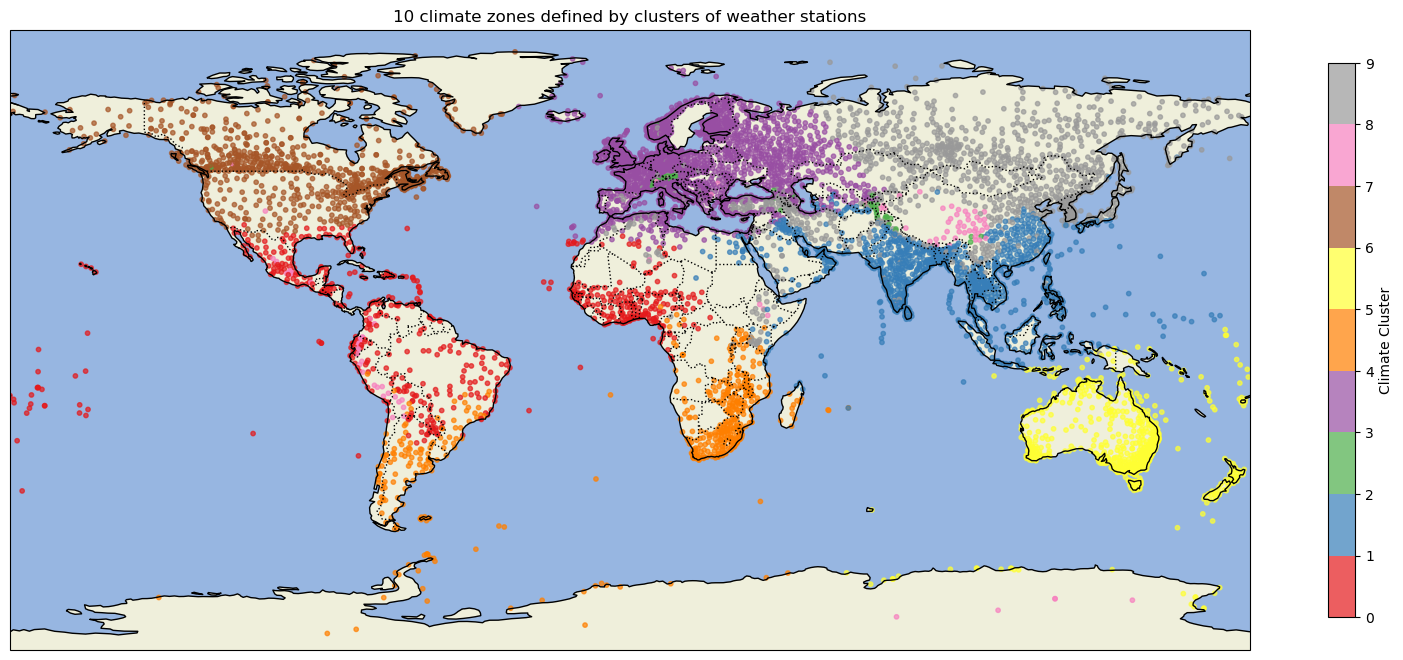

In [25]:

# Create a map of clusters identified by different colors

plt.figure(figsize=(20,12))
ax = plt.axes(projection=ccrs.PlateCarree())
#ax.set_extent([-25, 40, 34, 72], crs=ccrs.PlateCarree())
# Add features: coastlines, borders, land, ocean
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.COASTLINE)
ax.set_global()

# Plot points
scatter = ax.scatter(wmo_grouped_obs['longitude'], wmo_grouped_obs['latitude'],
                     c=wmo_grouped_obs['climate_cluster'], cmap='Set1', s=10, alpha=0.7, transform=ccrs.PlateCarree())
# Add legend
legend1 = plt.colorbar(scatter, ax=ax, orientation='vertical', label='Climate Cluster', shrink=0.6)

plt.title("10 climate zones defined by clusters of weather stations")
plt.show()


In [27]:
# Fetching WMO_IDs in each cluster and storing them
cluster_0 = wmo_grouped_obs[wmo_grouped_obs['climate_cluster']==0]['wmo_id'].reset_index() 
cluster_1 = wmo_grouped_obs[wmo_grouped_obs['climate_cluster']==1]['wmo_id'].reset_index() #Northern extreme latitudes
cluster_2 = wmo_grouped_obs[wmo_grouped_obs['climate_cluster']==2]['wmo_id'].reset_index() 
cluster_3 = wmo_grouped_obs[wmo_grouped_obs['climate_cluster']==3]['wmo_id'].reset_index() 
cluster_4 = wmo_grouped_obs[wmo_grouped_obs['climate_cluster']==4]['wmo_id'].reset_index() 
cluster_5 = wmo_grouped_obs[wmo_grouped_obs['climate_cluster']==5]['wmo_id'].reset_index() 
cluster_6 = wmo_grouped_obs[wmo_grouped_obs['climate_cluster']==6]['wmo_id'].reset_index() 
cluster_7 = wmo_grouped_obs[wmo_grouped_obs['climate_cluster']==7]['wmo_id'].reset_index()
cluster_8 = wmo_grouped_obs[wmo_grouped_obs['climate_cluster']==8]['wmo_id'].reset_index()
cluster_9 = wmo_grouped_obs[wmo_grouped_obs['climate_cluster']==9]['wmo_id'].reset_index()

cluster_0

,index,wmo_id
0,2664,31829
1,2702,32580
2,3009,38261
3,3012,38267
4,3020,38367
...,...,...
1166,7724,98752
1167,7725,98753
1168,7726,98755
1169,7727,98836


In [84]:
cluster_9

,index,wmo_id
0,1897,20046
1,1898,20069
2,1899,20087
3,1901,20292
4,1902,20471
...,...,...
753,4353,54857
754,4354,54863
755,4358,54945
756,4479,58150


In [29]:
#### Fetching observations belonging to clusters

cluster_0_obs = obs[obs['wmo_id'].isin(cluster_0['wmo_id'])]
cluster_1_obs = obs[obs['wmo_id'].isin(cluster_1['wmo_id'])]
cluster_2_obs = obs[obs['wmo_id'].isin(cluster_2['wmo_id'])]
cluster_3_obs = obs[obs['wmo_id'].isin(cluster_3['wmo_id'])]
cluster_4_obs = obs[obs['wmo_id'].isin(cluster_4['wmo_id'])]
cluster_5_obs = obs[obs['wmo_id'].isin(cluster_5['wmo_id'])]
cluster_6_obs = obs[obs['wmo_id'].isin(cluster_6['wmo_id'])]
cluster_7_obs = obs[obs['wmo_id'].isin(cluster_7['wmo_id'])]
cluster_8_obs = obs[obs['wmo_id'].isin(cluster_8['wmo_id'])]
cluster_9_obs = obs[obs['wmo_id'].isin(cluster_9['wmo_id'])]



,ob_value,time,wmo_id,diagnostic,latitude,longitude,altitude,land_fraction,roughness,day_of_year,hour,sin_day,cos_day,sin_hour,cos_hour,sin_lat,cos_lat,sin_long,cos_long,temp_celcius
1438110,301.5,2025-02-01 00:00:00+00:00,61974,temperature_at_screen_level,-10.383,56.600,3.0,0.000000,0.03,32,0,0.52342,0.85208,0.83485,0.55048,-0.18023,0.98362,0.83485,0.55048,28.35
1438111,300.7,2025-02-01 03:00:00+00:00,61974,temperature_at_screen_level,-10.383,56.600,3.0,0.000000,0.03,32,3,0.52342,0.85208,0.97958,-0.20108,-0.18023,0.98362,0.83485,0.55048,27.55
1438175,298.9,2025-02-01 00:00:00+00:00,96996,temperature_at_screen_level,-12.189,96.834,3.0,0.000000,0.03,32,0,0.52342,0.85208,0.99290,-0.11899,-0.21114,0.97746,0.99290,-0.11899,25.75
1438176,298.6,2025-02-01 01:00:00+00:00,96996,temperature_at_screen_level,-12.189,96.834,3.0,0.000000,0.03,32,1,0.52342,0.85208,0.92827,-0.37192,-0.21114,0.97746,0.99290,-0.11899,25.45
1438177,299.5,2025-02-01 02:00:00+00:00,96996,temperature_at_screen_level,-12.189,96.834,3.0,0.000000,0.03,32,2,0.52342,0.85208,0.80038,-0.59950,-0.21114,0.97746,0.99290,-0.11899,26.35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6937522,302.2,2025-03-02 12:00:00+00:00,32580,temperature_at_screen_level,53.060,158.790,65.0,0.635108,0.03,61,12,0.86746,0.49751,-0.36179,0.93226,0.79927,0.60098,0.36179,-0.93226,29.05
6945552,304.9,2025-03-06 12:00:00+00:00,32580,temperature_at_screen_level,53.060,158.790,65.0,0.635108,0.03,65,12,0.89963,0.43665,-0.36179,0.93226,0.79927,0.60098,0.36179,-0.93226,31.75
6953577,303.1,2025-03-10 12:00:00+00:00,32580,temperature_at_screen_level,53.060,158.790,65.0,0.635108,0.03,69,12,0.92754,0.37372,-0.36179,0.93226,0.79927,0.60098,0.36179,-0.93226,29.95
6965610,302.5,2025-03-16 12:00:00+00:00,32580,temperature_at_screen_level,53.060,158.790,65.0,0.635108,0.03,75,12,0.96113,0.27610,-0.36179,0.93226,0.79927,0.60098,0.36179,-0.93226,29.35


In [86]:
print(cluster_0_obs.shape)
print(cluster_1_obs.shape)
print(cluster_2_obs.shape)
print(cluster_3_obs.shape)
print(cluster_4_obs.shape)
print(cluster_5_obs.shape)
print(cluster_6_obs.shape)
print(cluster_7_obs.shape)
print(cluster_8_obs.shape)
print(cluster_9_obs.shape)

(312672, 20)
(761509, 20)
(335717, 20)
(4381761, 20)
(260454, 20)
(1416586, 20)
(559854, 20)
(90039, 20)
(472316, 20)
(641722, 20)


## Random Forest Regressor using Scikit-Learn (Model for each cluster)

### Data Preparation

In [33]:
# Method to split data into train, val, test

def split_by_wmo_id(df, train_frac=0.7, val_frac=0.15, seed=0):
    """
    Split into train/val/test sets by unique WMO IDs.
    """

    unique_ids = df['wmo_id'].unique()
    np.random.seed(seed)
    np.random.shuffle(unique_ids)

    n_train = int(train_frac * len(unique_ids))
    n_val = int(val_frac * len(unique_ids))

    train_ids = unique_ids[:n_train]
    val_ids = unique_ids[n_train:n_train + n_val]
    test_ids = unique_ids[n_train + n_val:]

    df_train = df[df['wmo_id'].isin(train_ids)]
    df_val = df[df['wmo_id'].isin(val_ids)]
    df_test = df[df['wmo_id'].isin(test_ids)]

    return df_train, df_val, df_test


In [35]:
df_train, df_val, df_test = {}, {}, {}

for i in range(num_clusters):
    df_train_, df_val_, df_test_ = split_by_wmo_id(globals()[f"cluster_{i}_obs"])
    df_train[i] = df_train_
    df_val[i] = df_val_
    df_test[i] = df_test_

print(df_train[0].shape)
print(df_val[0].shape)
print(df_test[0].shape)


(218025, 20)
(44817, 20)
(49830, 20)


### Storing data for visualisation

In [38]:
map_values = {}

for i in range(num_clusters):
    map_values[i] = df_test[i][['latitude', 'longitude','altitude', 'temp_celcius', 'day_of_year', 'hour']]
    
map_values[0]

,latitude,longitude,altitude,temp_celcius,day_of_year,hour
1132102,-20.540,-70.179,48.0,22.65,32,0
1132103,-20.540,-70.179,48.0,21.45,32,3
1132199,-20.540,-70.179,48.0,20.85,32,6
1132200,-20.540,-70.179,48.0,20.95,32,9
1132295,-20.540,-70.179,48.0,21.45,32,12
...,...,...,...,...,...,...
2922867,32.133,-81.200,15.0,31.05,139,21
2923041,32.133,-81.200,15.0,28.25,140,0
2923042,32.133,-81.200,15.0,25.55,140,3
2923218,32.133,-81.200,15.0,23.85,140,6


In [40]:

scaler = MinMaxScaler()
X_train, y_train, X_val, y_val, X_test, y_test = {}, {}, {}, {}, {}, {}

for i in range(num_clusters):
    df_train[i] = df_train[i].drop(columns=['ob_value', 'time', 'wmo_id', 'diagnostic', 'latitude', 'longitude', 'day_of_year', 'hour'])
    df_val[i] = df_val[i].drop(columns=['ob_value', 'time', 'wmo_id', 'diagnostic', 'latitude', 'longitude', 'day_of_year', 'hour'])
    df_test[i] = df_test[i].drop(columns=['ob_value', 'time', 'wmo_id', 'diagnostic', 'latitude', 'longitude', 'day_of_year', 'hour'])

    X_train[i] = df_train[i].iloc[:, :11].values
    y_train[i] = df_train[i].iloc[:, 11].values
    X_val[i] = df_val[i].iloc[:, :11].values
    y_val[i] = df_val[i].iloc[:, 11].values
    X_test[i] = df_test[i].iloc[:, :11].values
    y_test[i] = df_test[i].iloc[:, 11].values

    X_train[i] = scaler.fit_transform(X_train[i])
    X_val[i] = scaler.transform(X_val[i])
    X_test[i] = scaler.transform(X_test[i])

### Training

In [47]:
models = {}

for i in range(num_clusters):
    models[i] = RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        criterion='squared_error',
        max_depth=30,
        min_samples_split=2,
        min_samples_leaf=1,
        bootstrap=True,
        warm_start=True,
        n_jobs=-1,
        max_samples=0.5
    )
    models[i].fit(X_train[i], y_train[i])
    print(f"Fitted model {i}")


Fitted model 0
Fitted model 1
Fitted model 2
Fitted model 3
Fitted model 4
Fitted model 5
Fitted model 6
Fitted model 7
Fitted model 8
Fitted model 9


### Evaluate 

In [51]:
# Make predictions on the test data
preds, mae = {}, {}
for i in range(num_clusters):
    preds[i] = models[i].predict(X_test[i])
    
    mae[i] = mean_absolute_error(y_test[i], preds[i])
    print(f"Mean Absolute Error for cluster {i} : {mae[i]}")

Mean Absolute Error for cluster 0 : 1.821047878031552
Mean Absolute Error for cluster 1 : 1.4944138536525693
Mean Absolute Error for cluster 2 : 1.6791010528694519
Mean Absolute Error for cluster 3 : 1.183051198451452
Mean Absolute Error for cluster 4 : 2.1463561858736813
Mean Absolute Error for cluster 5 : 1.7899302214136947
Mean Absolute Error for cluster 6 : 2.2901179469324724
Mean Absolute Error for cluster 7 : 2.819692280814948
Mean Absolute Error for cluster 8 : 2.66142115141032
Mean Absolute Error for cluster 9 : 2.5047777896310532


### Visualisation

In [55]:
tempdf = {}
for i in range(num_clusters):
    
    tempdf[i] = pd.DataFrame({
        'latitude' : map_values[i]['latitude'],
        'longitude' : map_values[i]['longitude'],
        'altitude' : map_values[i]['altitude'],
        'day_of_year' : map_values[i]['day_of_year'],
        'y_test' : y_test[i],
        'predicted' : preds[i].reshape(-1),
        'error' : y_test[i]-preds[i].reshape(-1)
    })


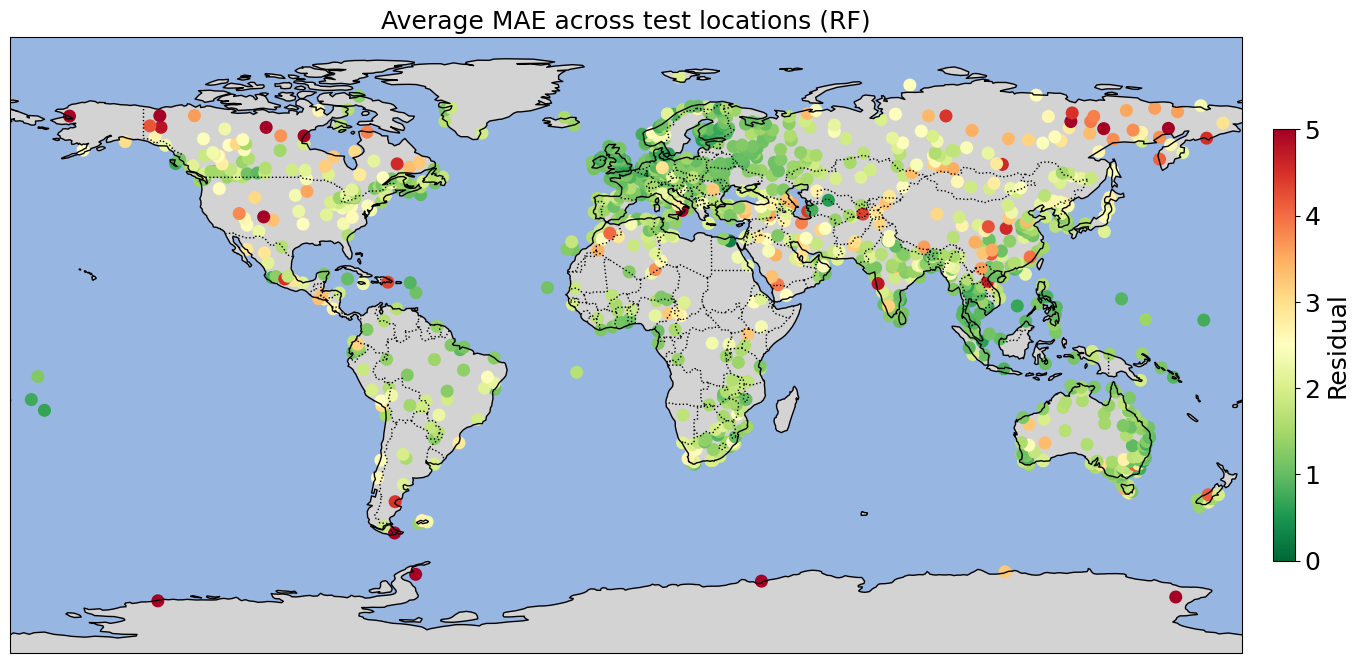

In [60]:
# MAE spatial distribution map

unique_test_locs = tempdf.copy()

for i in range(num_clusters):

    unique_test_locs[i]['error'] = np.abs(unique_test_locs[i]['error'])
    unique_test_locs[i] = unique_test_locs[i].groupby(['latitude', 'longitude'])['error'].mean().reset_index()
    

# Create a map
plt.figure(figsize=(20, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
#ax.set_extent([-11, 3, 49.5, 61.5], crs=ccrs.PlateCarree())
# Add features: coastlines, borders, land, ocean
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.COASTLINE)
ax.set_global()

for i in range(10):
    z = np.abs(unique_test_locs[i]['error'])
    # Plot points
    sc = ax.scatter(unique_test_locs[i]['longitude'], unique_test_locs[i]['latitude'], s=70, c=z, alpha=1, transform=ccrs.PlateCarree(), cmap='RdYlGn_r', vmin=0, vmax=5)

# Colorbar for residual intensity
#plt.colorbar(sc, ax=ax, orientation='vertical', label='Residual')
plt.title("Average MAE across test locations (RF)", fontsize=18)
cbar = plt.colorbar(sc, ax=ax, orientation='vertical', pad=0.02, shrink=0.7)
cbar.set_label('Residual', fontsize=18)   # colorbar title size
cbar.ax.tick_params(labelsize=18) 
plt.show()

In [ ]:
# Actual vs. Predicted Temperature with Uncertainty (RF-CLusters)

tempdf_grouped = tempdf.groupby(['y_test'], as_index = False).agg({
    'predicted' : ['mean', 'std']
})

errors = abs(tempdf_grouped['predicted']['mean'] - tempdf_grouped['y_test'])
errors = errors.astype(int)
plt.figure(figsize=(8, 6))
plt.errorbar(tempdf_grouped['y_test'], tempdf_grouped['predicted']['mean'], yerr=2*tempdf_grouped['predicted']['std'], fmt='o', alpha=0.5, markersize=4,
             ecolor='gray', capsize=2, label='Predicted ± Std Dev', color='blue')

# Reference line: perfect prediction
plt.plot([tempdf_grouped['y_test'].min(), tempdf_grouped['y_test'].max()], [tempdf_grouped['y_test'].min(), tempdf_grouped['y_test'].max()],'r--', label='Ideal Prediction')

#plt.xscale('log')
#plt.yscale('log')

plt.xlabel('Actual Temperature (C)', fontsize=12)
plt.ylabel('Predicted Temperature (C) (Mean ± Std)', fontsize=12)
plt.title('Actual vs. Predicted Temperature with Uncertainty (Global Model)', fontsize=14)
plt.xlim
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
## Mean of MAE within temperature bins. the temperature range has been divided into 234 bins.

temp_bins = pd.cut(tempdf['y_test'], bins=234)
tempdf1 = tempdf.copy()
tempdf1['error'] = np.abs(tempdf1['error'])
temp_bin_error = tempdf1.groupby([temp_bins])['error'].agg(['mean', 'std']).reset_index()
temp_bin_error['temp_center'] = temp_bin_error['y_test'].apply(lambda x : x.mid)
temp_bin_error

plt.figure(figsize=(12, 8))
plt.errorbar(temp_bin_error['temp_center'], temp_bin_error['mean'], yerr=temp_bin_error['std'], fmt='o', alpha=0.5, markersize=4,
             ecolor='gray', capsize=4, label='Predicted ± Std Dev', color='blue')

# Reference line: perfect prediction
#plt.plot([tempdf_grouped['y_test'].min(), tempdf_grouped['y_test'].max()], [tempdf_grouped['y_test'].min(), tempdf_grouped['y_test'].max()],'r--', label='Perfect Prediction')

#plt.xlim(20,50)
plt.ylim(-1,9)
plt.xlabel('Actual Temperature bands with a width of 5 degrees', fontsize=12)
plt.ylabel('Mean Absolute Error (Mean ± Std) (C)', fontsize=12)
plt.title('Temperature bands vs. Mean Absolute Error for with Uncertainty (UK Model)', fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
#  Actual vs predicted temperature

plt.figure(figsize=(12, 8))
plt.scatter(y_test, preds, s=10, alpha=0.2, edgecolors='none')
x_ = np.linspace(y_test.min(), y_test.max(), 100)
y_ = x_
plt.plot(x_, y_, color = 'black')
plt.grid(True)
#plt.xlim(-70,-35)
#plt.ylim(-80,-5)
plt.xlabel('Actual Temperature (C)')
plt.ylabel('Predicted Temperature (C)')
plt.title('Actual vs Predicted Temperature (Test Set)')

In [ ]:
# Residual density plot

# Define custom colors: light green → yellow → dark red
colors = ["green", "yellow", "red"]
custom_cmap = LinearSegmentedColormap.from_list("green_red", colors)
plt.figure(figsize=(15,8))
plt.hexbin(tempdf['predicted'], tempdf['y_test'] - tempdf['predicted'], gridsize=500, cmap='RdYlGn_r')
plt.colorbar(label='Counts')
plt.xlabel('Temperature Predictions (C)')
plt.ylabel('Residuals (C)')
plt.ylim(-7,7.5)
plt.xlim(-5,25)
plt.title('Hexbin Density Plot (Residuals) (UK Model)')
plt.grid(True)
plt.show()

In [ ]:
# Basic residual plot

resids = tempdf[0]['y_test'] - tempdf[0]['predicted'] 
plt.scatter(tempdf[0]['predicted'], resids, s=7, alpha=0.1, edgecolors='none')
plt.axhline(y=0, color='black')
plt.grid(True)
#plt.ylim(-7.5,10)
plt.xlabel('Temperature Predictions (C)')
plt.ylabel('Residuals (C)')
plt.title('Residual Plot')
plt.show()